# 1. Phân tích dữ liệu ban đầu (Exploratory Data Analysis) cho file CSV
## 1.1 Tổng quan chung
Trước khi huấn luyện mô hình machine learning, cần phải hiểu cấu trúc của
dữ liệu. Quá trình này được gọi là Exploratory Data Analysis (EDA)

EDA giúp trả lời các câu hỏi:
- Dataset có bao nhiêu mẫu?
- Có những đặc trưng nào?
- Có dữ liệu thiếu hay không?
- Phân bố của các đặc trưng như thế nào?
- Các đặc trưng có liên quan đến biến mục tiêu hay không?

In [1]:
import pandas as pd

train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

## 1.2 Tổng quan tệp train và test
- Tệp train sẽ bao gồm 891 hàng và 12 cột dữ liệu
- Tệp test sẽ bao gồm 418 hàng và 11 cột dữ liệu

In [2]:
print ("Train shape (row,col):", train.shape)
print ("Test shape:", test.shape)

Train shape (row,col): (891, 12)
Test shape: (418, 11)


train.head()
Lệnh này giúp hiểu cấu trúc của dataset. Ta thấy được nội dung của 
các cột quan trọng:
- Survived : biến mục tiêu
- PClass : hạng vé
- Sex : giới tính
- Age : tuổi
- Fare : giá vé

In [3]:
train.head ()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1.3 Số liệu thống kê dữ liệu
count: Tổng số mẫu không bị thiếu.

mean (trung bình): Giá trị trung bình của cột đó. Ví dụ, giá trị trung bình của Survived là 0.38, nghĩa là khoảng 38% hành khách trong tập train đã sống sót.  

std (độ lệch chuẩn): Cho biết mức độ phân tán của dữ liệu so với giá trị trung bình.

min (nhỏ nhất): Giá trị thấp nhất trong cột.

25%, 50%, 75% (tứ phân vị): phân bố dữ liệu.

max (lớn nhất): Giá trị cao nhất trong cột

In [4]:
train.describe ()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# 2. Phân tích biến mục tiêu (Survial)
Trước khi huấn luyện mô hình, cần kiểm tra sự cân bằng của dữ liệu. Mục tiêu là phân tích dữ liệu người sống sót hoặc thiệt mạng, nên ta sẽ tập trung vào biến *Survial*

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

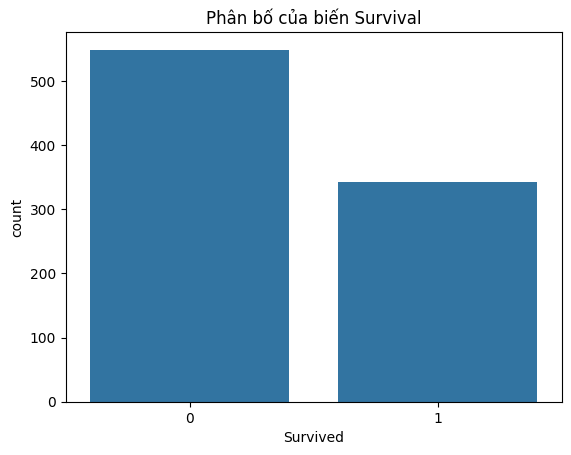

In [6]:
sns.countplot(x='Survived', data=train)
plt.title("Phân bố của biến Survival")
plt.show()

Mặc dù có sự chênh lệch giữa số người thiệt mạng và số người sống sót, nhưng tỉ lệ này không nằm ở mức quá chênh lệch, nên dữ liệu này không mất cân bằng. Vì thế ta có thể sử dụng accuracy của dataset này để đánh giá chất lượng.

# 3. Phân tích mối quan hệ giữa đặc trưng và biến mục tiêu

## 3.1 Phân tích người sống sót theo giới tính
Phụ nữ có tỉ lệ sống sót cao hơn nam giới, trong khi đó Nam giới thiệt mạng nhiều hơn.
Như vậy, biến Sex (Giới tính) sẽ cho quyết định tỉ lệ sống sót cao hay không.

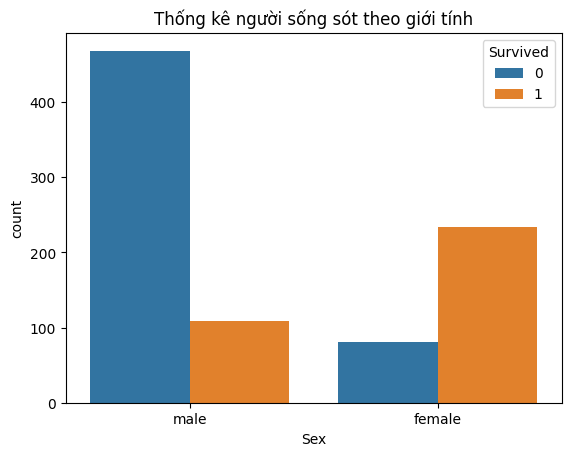

In [7]:
sns.countplot(x='Sex', hue='Survived', data=train)
plt.title("Thống kê người sống sót theo giới tính")
plt.show()

## 3.2 Phân tích người sống sót theo hạng vé
Hành khách ở Hạng 1 có cơ hội sống sót cao nhất. Ngược lại, hành khách ở Hạng 3 có số lượng người thiệt mạng nhiều, tỉ lệ sống sót thấp. Vì vậy, Pclass là một đặc trưng quan trọng mà cần đưa vào huấn luyện.

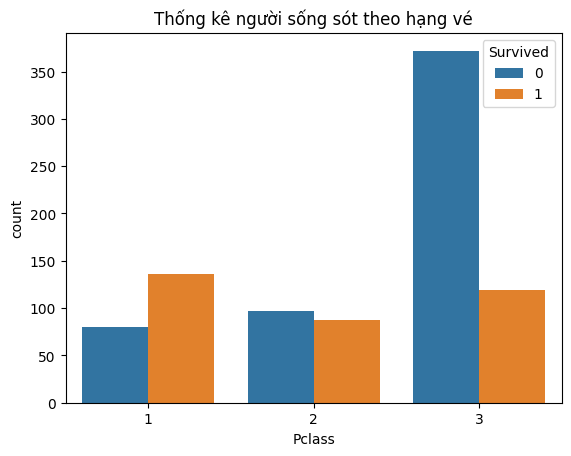

In [8]:
sns.countplot(x='Pclass', hue='Survived', data=train)
plt.title("Thống kê người sống sót theo hạng vé")
plt.show()

## 3.3 Phân bố tuổi tác
- Phần lớn hành khách nằm trong khoảng 20–40 tuổi.
- Từ 40 - 60 tuổi chiếm một phần nhỏ và trên 60 tuổi rất ít.
- Có một số lượng nhỏ trẻ em

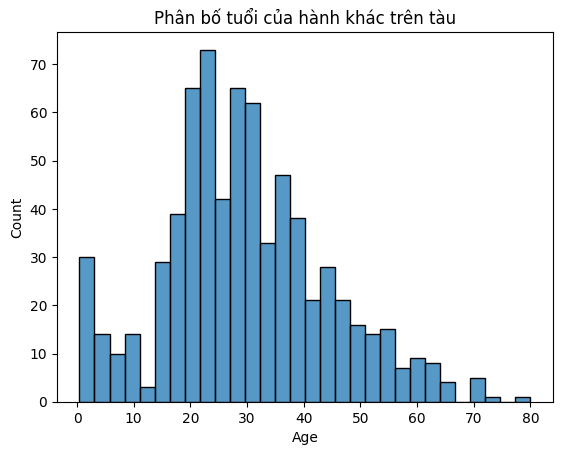

In [9]:
sns.histplot(train['Age'], bins=30)
plt.title("Phân bố tuổi của hành khác trên tàu")
plt.show()

## 3.4 Phân bố giá vé
Biểu đồ cho thấy hầu hết người trên tàu đều mua với giá vé dưới 100 đô, hầu như là mua vé với giá rẻ dưới 30 đô
Chỉ có một số người mua giá vé 200-300 và trên 500 đô

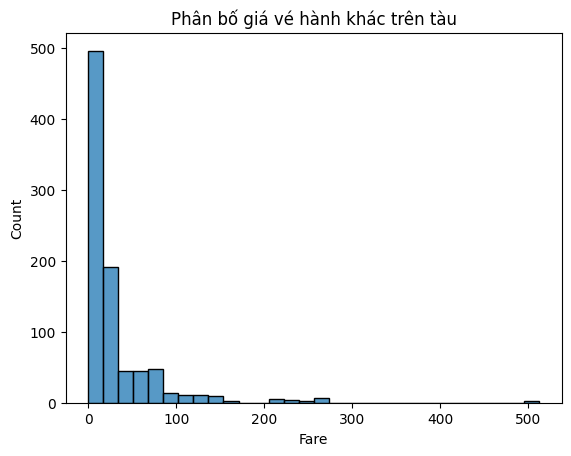

In [10]:
sns.histplot(train['Fare'], bins=30)
plt.title("Phân bố giá vé hành khác trên tàu")
plt.show()

# 4. Xử lý dữ liệu thiếu
Dữ liệu thiếu là vấn đề rất phổ biến trong machine learning, như trong dataset này, thống kê thấy rằng có 177 người thiếu tuổi, 687 người không rõ số buồng và 2 người không rõ cập bến từ đâu. Các dữ liệu còn lại được cung cấp đầy đủ

In [11]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## 4.1 Xử lý cột Age
Phương pháp xử lý đề xuất cho việc điền vào Age là thêm giá trị trung bình tuổi của dữ liệu là 29.6 tuổi
Do lệnh sử dụng phiên bản mới của thư viện Pandas, việc sử dụng inplace=True trên một cột dữ liệu đ sẽ không còn được hỗ trợ
```
train[’Age’].fillna(train[’Age’].mean(), inplace=True)
test[’Age’].fillna(test[’Age’].mean(), inplace=True)
```
nên ta sẽ thay thế bằng dòng lệnh sau

```
train['Age'] = train['Age'].fillna(train['Age'].mean())
test['Age'] = test['Age'].fillna(test['Age'].mean())
```

Sau khi chạy lệnh, ta sẽ kiểm tra lại 1 lần nữa để kiểm tra coi đã điền hết cột Age chưa

In [12]:
train['Age'] = train['Age'].fillna(train['Age'].mean())
test['Age'] = test['Age'].fillna(test['Age'].mean())

train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## 4.2 Xử lý cột Embarked
Với mode()[0], lệnh sẽ trả về giá trị xuất hiện thường xuyên nhất trong một tập hợp dữ liệu. Sau đó sẽ chèn vào những phần dữ liệu trống.

Phương pháp này được sử dụng vì với số lượng khuyết là 2 người, việc tăng thêm 2 người trong dữ liệu được xuất hiện nhiều nhất sẽ không ảnh hưởng gì nhiều tới việc suy luận của mô hình.

Sau khi chạy, ta cũng sử dụng lệnh kiểm tra lại.

In [13]:
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])

train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

## 4.3 Xử lý Cabin
Với dữ liệu Cabin bị thiếu nhiều, ta không thể lấy dữ liệu được xuất hiện nhiều nhất như Embarked. Xử lý dữ liệu như vậy sẽ ảnh hưởng tới chất lượng học của mô hình và vô tình làm biến dữ liệu trở nên phi lý.

Thực tế, số hành khách được gắn cabin là số hành khách mua vé hạng cao, số lượng còn lại không gán cabin vì là hành khách hạng thấp, có thể là nhân viên trên tàu. Những người có số cabin có tỉ lệ sống sót nhiều hơn vì là gần boong ke tàu.

Với số lượng dữ liệu lớn là không biết như vậy, ta nên gán ký tự 'U': Unknown, dự đoán tỉ lệ sống sót của Unknown sẽ thấp hơn số lượng người có mã cabin

In [14]:
train['Cabin'] = train['Cabin'].str.slice(0,1).fillna('U')
test['Cabin'] = test['Cabin'].str.slice(0,1).fillna('U')

train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

# 5. Feature Engineering
Feature engineering là quá trình tạo thêm các đặc trưng mới để giúp mô
hình học tốt hơn.
## 5.1 Feature Family size
Một feature hữu ích trong dataset Titanic là kích thước gia đình.

Giải thích:
- SibSp: số anh chị em hoặc vợ/chồng
- Parch: số cha mẹ hoặc con cái
- +1 để tính bản thân hành khách

In [15]:
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1

train.head ()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,U,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,U,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,U,S,1


## 5.2 Feature IsAlone
Với kích thước gia đình là 1, ta sẽ gán giá trị IsAlone = 1

In [16]:
train['IsAlone']= (train['FamilySize']==1).astype(int)
test['IsAlone']= (train['FamilySize']==1).astype(int)

train.head ()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,U,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,U,S,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,U,S,1,1


# 6. Chuẩn bị dữ liệu cho mô hình
Encode biến categorical
- fit_transform() - encode cho tập train. Thiết lập mã hóa dựa trên tập train.
- transform -encode cho tập test. Đảm bảo tập Test được xử lý theo đúng quy luật của tập Train.

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train['Sex'] = le.fit_transform(train['Sex'])
test['Sex'] = le.transform(test['Sex'])

Trích xuất các đặc trưng: Pclass, giới tính, tuổi tác, giá vé, FamilySize

In [18]:
features = [
'Pclass',
'Sex',
'Age',
'Fare',
'FamilySize'
]

Hàm clean_titles thực hiện đơn giản hóa dữ liệu để mô hình AI dễ học hơn và không bị lỗi. Gom nhóm các danh xưng tương đương và xử lý các danh xưng hiếm, nếu có sẽ được đưa vào mục misc

In [19]:
train['Title'] = train['Name'].str.extract(r' ([A-Za-z]+)\.')
test['Title'] = test['Name'].str.extract(r' ([A-Za-z]+)\.')

def clean_titles(df):
    common_titles = ['Mr', 'Miss', 'Mrs', 'Master']
    df['Title'] = df['Title'].replace(['Ms', 'Mlle', 'Mme'], 'Miss')
    df.loc[~df['Title'].isin(common_titles), 'Title'] = 'Misc'
    return df

train = clean_titles(train)
test = clean_titles(test)

le = LabelEncoder()
train['Title'] = le.fit_transform(train['Title'])
test['Title'] = le.transform(test['Title'])

# 7. Correlation Analysis
Theo dữ liệu bên dưới, ta thấy được rõ sự tương quan giữa các đặc trưng với nhau. Ví dụ như Feature tương quan với Survival mạnh nhất là biến Sex

<Axes: >

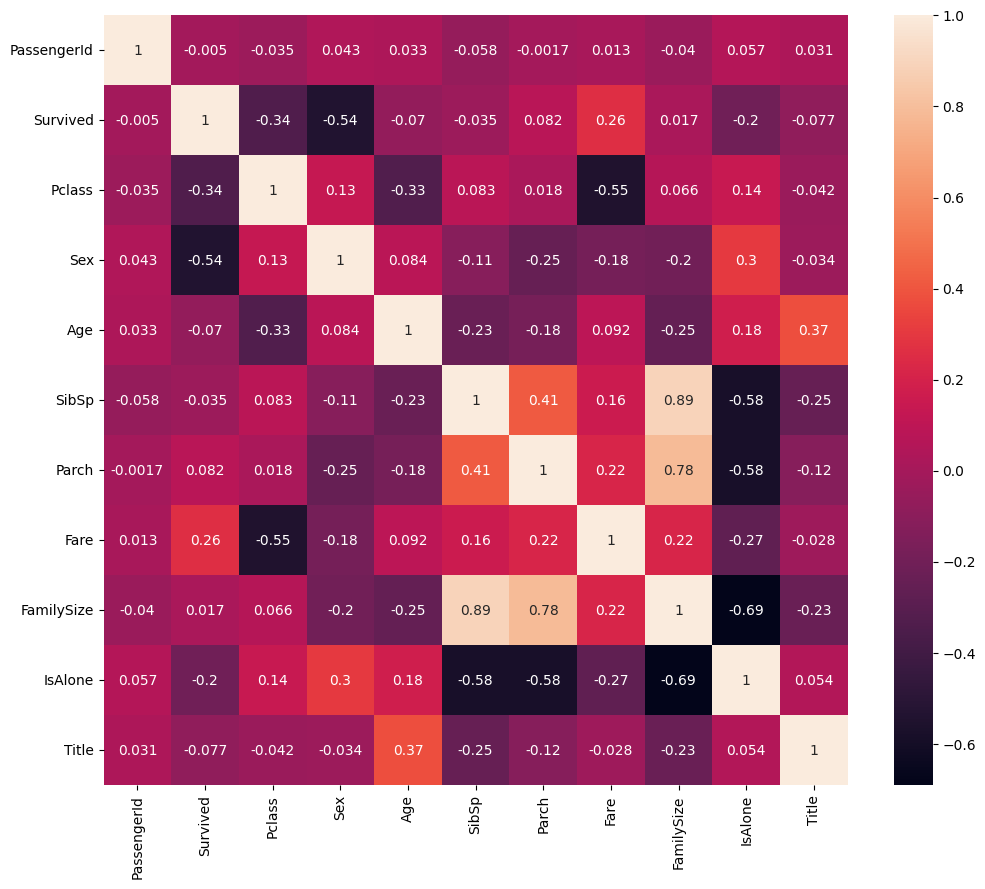

In [20]:
plt.figure(figsize=(12, 10))
sns.heatmap(train.corr(numeric_only=True), annot=True)

# 8. Huấn luyện mô hình
- Chia tập train và validation

In [21]:
from sklearn.model_selection import train_test_split

X = train[features]
y = train['Survived']
X_train, X_val, y_train, y_val = train_test_split(
X, y, test_size=0.2, random_state=42
)

## DecisonTree


In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree = DecisionTreeClassifier(max_depth=4)
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_val)
print("Accuracy:", accuracy_score(y_val, pred_tree))

Accuracy: 0.7988826815642458


## LogisticRegression
- Accuracy chỉ sau RandomForest

In [45]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)
pred = lr.predict(X_val)
print("Accuracy:", accuracy_score(y_val, pred))

Accuracy: 0.8044692737430168


## RandomForestClassifier
- Kết quả accuracy ra cao nhất trong 5 Model

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_val)
print("Accuracy:", accuracy_score(y_val, pred_rf))

Accuracy: 0.8100558659217877


## KNearestNeighbors
-KNN cho ra accuracy thấp nhất

In [25]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5) 
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_val)
print("Accuracy:", accuracy_score(y_val, pred_knn))

Accuracy: 0.7039106145251397


## SupportVectorMachine

In [26]:
from sklearn.svm import SVC

svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_val)
print("Accuracy:", accuracy_score(y_val, pred_svm))

Accuracy: 0.7821229050279329


# 9. Hyperparameter Tuning
Sử dụng GridSearchCV để tìm tham số tốt nhất cho Random Forest. Sử dụng khung các giá trị đã khai báo trong param_grid.

Bằng cách chọn tổ hợp 2 tham số số lượng cây trong rừng và độ sâu tối đa của mỗi cây, kết quả trả về cặp tham số tốt nhất là 5 cây và độ sâu tối đa 200, trả về accuracy là 83,7%.
Cao hơn so với RandomForest chưa được Tuning.

In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10]
}


rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy')

grid_search.fit(X_train, y_train)

print("Best paramaters:", grid_search.best_params_)

print("Highest accuracy:", grid_search.best_score_)

Best paramaters: {'max_depth': 5, 'n_estimators': 200}
Highest accuracy: 0.837043238451689


# 10. Cross Validation
Khi thực hiện với giá trị $k=5$. Dữ liệu sẽ được chia thành 5 phần bằng nhau. Quá trình lặp lại 5 lần, trong mỗi lần một phần được giữ lại để làm dữ liệu kiểm thử, 4 phần còn lại được dùng để huấn luyện mô hình. Kết quả cuối cùng là giá trị trung bình của các lần chạy.


Kết quả cho ta thấy, các điểm số của từng lượt dao động khoảng 0.77 đến 0.85. Mô hình hoạt động khá ổn định và không thay đổi nhiều khi dữ liệu đầu vào trong các phần khác nhau.


In [29]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)

print(f"Điểm số của từng lượt: {scores}")
print(f"Độ chính xác trung bình: {scores.mean():.4f}")

Điểm số của từng lượt: [0.77653631 0.82022472 0.86516854 0.79775281 0.85393258]
Độ chính xác trung bình: 0.8227


# 11. Feature Importance
Vẽ feature của Random Forest, ta thấy được feature quan trọng nhất trong mô hình này là Fare: Giá vé, sau đó là Sex: giới tính và Age: độ tuổi. 3 Feature này chiếm nhiều tới quyết định đưa ra là sống sót hay thiệt mạng.

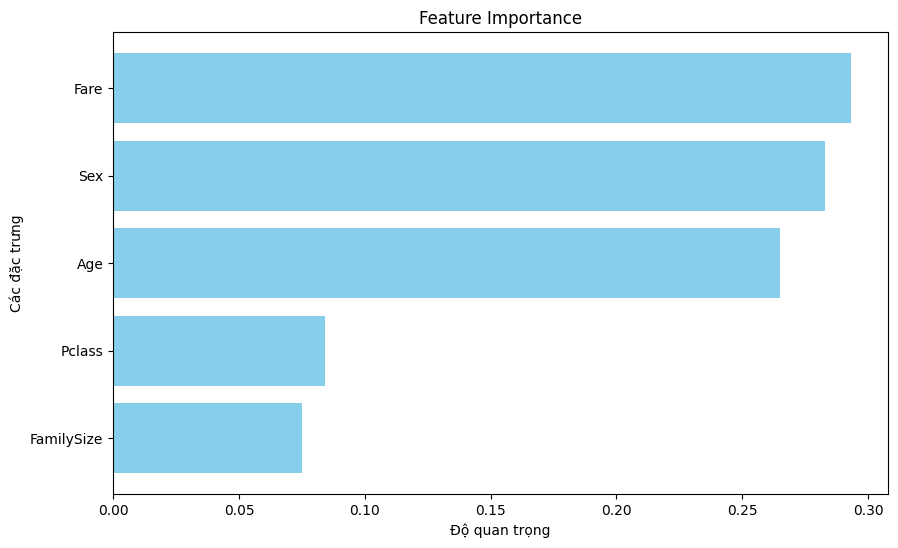

In [39]:

importances = rf.feature_importances_

feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Độ quan trọng')
plt.ylabel('Các đặc trưng')
plt.title('Feature Importance')
plt.gca().invert_yaxis() 
plt.show()

So sánh Feature Importance với 2 mô hình Decision Tree và Logistic Regression.

Với Decision Tree, ta thấy Feature quan trọng nhất trong mô hình này không phải là Fare: Giá vé mà là Sex: giới tính, trong khi đó Fare chỉ đứng thứ 3 trong mức độ quan trọng của mô hình này. 

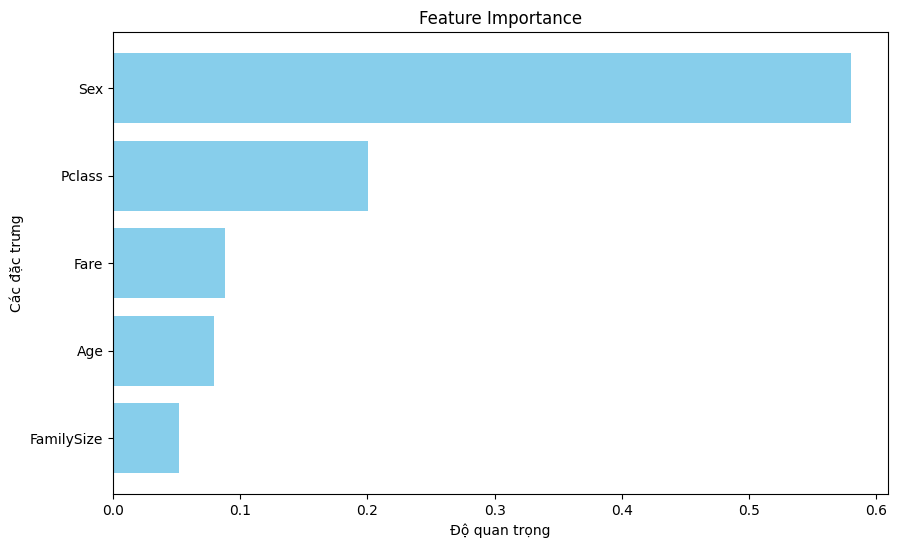

In [41]:
importances = tree.feature_importances_

feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Độ quan trọng')
plt.ylabel('Các đặc trưng')
plt.title('Feature Importance')
plt.gca().invert_yaxis() 
plt.show()

So sánh với Linear Regression, ta cũng thấy Fare không phải là Feature quan trọng, thậm chí trong mô hình này, mức độ quan trọng của Feature này rất thấp, hầu như là không quyết định được gì. Trong khi đó, Feature quan trọng nhất của mô hình giống với Decision Tree.

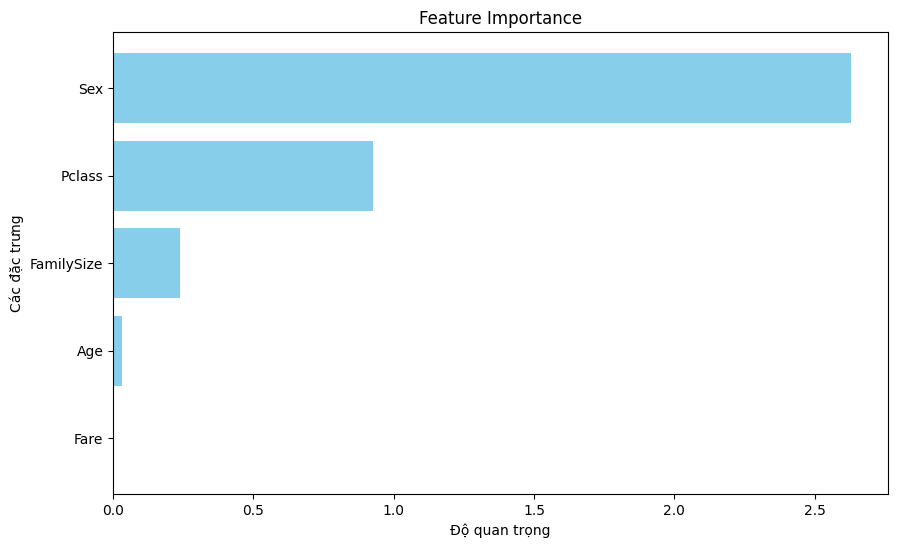

In [49]:
import numpy as np
importances = np.abs(lr.coef_[0])

feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Độ quan trọng')
plt.ylabel('Các đặc trưng')
plt.title('Feature Importance')
plt.gca().invert_yaxis() 
plt.show()

# 12. Kết luận 
Logistic Regression hoạt động hiệu quả nhờ tính đơn giản và hiệu quả, mô hình này không yêu cầu tài nguyên tính toán lớn, dễ triển khai và chạy rất nhanh trên các tập dữ liệu từ nhỏ đến trung bình. Có đầu ra là dạng xác suất, mô hình sử dụng hàm Sigmoid để trả về giá trị xác suất. Điều này giúp người dùng đánh giá được mức độ tin cậy của dự đoán, các hệ số của mô hình cho biết mức độ ảnh hưởng trực tiếp của từng biến đầu vào đến kết quả cuối cùng.


Decision Tree rất dễ rơi vào tình trạng overfitting trong các trường hợp:

- Cây quá sâu: Khi cây được phép phát triển không giới hạn, nó sẽ cố gắng tạo ra các nhánh để phân loại đúng từng điểm dữ liệu cuối cùng, bao gồm cả các điểm nhiễu.

- Dữ liệu huấn luyện có nhiễu: Mô hình học các sai số ngẫu nhiên trong tập huấn luyện thay vì học quy luật tổng quát.

- Kích thước mẫu ở nút lá quá nhỏ: Nếu một nút lá chỉ chứa một vài điểm dữ liệu, các quyết định ở đó sẽ mang tính đặc thù và không áp dụng được cho dữ liệu mới.


Random Forest được coi là tốt hơn nhờ cơ chế Ensemble Learning: 

- Giảm phương sai: Một cây quyết định đơn lẻ thường dễ thay đổi kết quả khi dữ liệu thay đổi nhỏ. Random Forest tính trung bình kết quả của hàng trăm cây, giúp mô hình ổn định và chính xác hơn.

- Cơ chế lấy mẫu ngẫu nhiên: Mỗi cây trong rừng được huấn luyện trên một tập con dữ liệu khác nhau, giúp mô hình tổng thể bao quát được nhiều khía cạnh của dữ liệu.

- Tính ngẫu nhiên của đặc trưng: Khi chia nhánh, Random Forest chỉ chọn một tập con ngẫu nhiên các đặc trưng. Điều này ngăn chặn việc một đặc trưng quá mạnh áp đảo toàn bộ các cây, giúp các cây trong rừng trở nên đa dạng và độc lập hơn.

- Khả năng chống overfitting: Nhờ việc kết hợp nhiều cây lại với nhau, các sai số của từng cây đơn lẻ sẽ triệt tiêu lẫn nhau, giúp mô hình tổng thể đạt hiệu suất tốt hơn trên dữ liệu thực tế.